# Q7: Intel Image Classification using Transfer Learning (PyTorch)

## Objective
Build an image classification model to classify outdoor scene images into the following classes:

1. Buildings
2. Forest
3. Glacier
4. Mountain
5. Sea
6. Street

Dataset: https://www.kaggle.com/datasets/puneet6060/intel-image-classification

# Part A: Data Preparation (5 Marks)

## Step 1: Install Kaggle and Download Dataset

In [30]:
!pip install kaggle

In [29]:
from google.colab import files
files.upload()

Saving download.jpg to download.jpg


{'download.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x08\x07\x06\t\x08\x07\x08\n\n\t\x0b\r\x16\x0f\r\x0c\x0c\r\x1b\x14\x15\x10\x16 \x1d"" \x1d\x1f\x1f$(4,$&1\'\x1f\x1f-=-157:::#+?D?8C49:7\x01\n\n\n\r\x0c\r\x1a\x0f\x0f\x1a7%\x1f%77777777777777777777777777777777777777777777777777\xff\xc0\x00\x11\x08\x00\x94\x00\xd3\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1b\x00\x00\x02\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x05\x00\x03\x06\x02\x01\x07\xff\xc4\x00@\x10\x00\x02\x01\x03\x02\x03\x05\x06\x05\x02\x05\x02\x06\x03\x00\x00\x01\x02\x03\x00\x04\x11\x12!\x05\x131\x06"AQa\x142q\x81\x91\xa1B\xb1\xc1\xd1\xf0#\xe1\x07\x15$R\xf13b\x16c\x82\x92\xa2\xb2&4S\xff\xc4\x00\x19\x01\x00\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x00\x05\xff\xc4\x00&\x11\x00\x02\x02\x03\x00\x02\x02\x01\x04\x03\x00\x00\x00\x00\x00\x00\x00\x01\x02\x11\x03!1\x12A\x1323"#Qa\x04\x81\xf0\xff\xda\x00\x0c\x03\x0

In [31]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [32]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

## Dataset Structure
```
seg_train/
    buildings
    forest
    glacier
    mountain
    sea
    street

seg_test/
    buildings
    forest
    glacier
    mountain
    sea
    street
```

## Step 2: Import Libraries

In [33]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

## Step 3: Data Augmentation and Preprocessing

In [34]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [35]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

## Step 4: Load Dataset

In [36]:
train_dataset = datasets.ImageFolder(
    "seg_train/seg_train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    "seg_test/seg_test",
    transform=test_transform
)

In [37]:
class_names = train_dataset.classes
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [38]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Part B: Transfer Learning (10 Marks)

In [39]:
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [40]:
for param in model.parameters():
    param.requires_grad = False

In [41]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    6
)

model = model.to(device)

In [42]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [43]:
train_loss = []
train_acc = []

val_loss = []
val_acc = []

In [44]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss/len(train_loader)
    epoch_acc = 100*correct/total

    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss={epoch_loss:.4f}, "
        f"Accuracy={epoch_acc:.2f}%"
    )

Epoch 1/10, Loss=0.6145, Accuracy=79.56%
Epoch 2/10, Loss=0.4013, Accuracy=85.79%
Epoch 3/10, Loss=0.3720, Accuracy=86.85%
Epoch 4/10, Loss=0.3623, Accuracy=86.80%
Epoch 5/10, Loss=0.3520, Accuracy=87.48%
Epoch 6/10, Loss=0.3436, Accuracy=87.34%
Epoch 7/10, Loss=0.3427, Accuracy=87.42%
Epoch 8/10, Loss=0.3341, Accuracy=87.62%
Epoch 9/10, Loss=0.3388, Accuracy=87.52%
Epoch 10/10, Loss=0.3312, Accuracy=87.59%


# Part C: Model Evaluation and Inference (10 Marks)

In [45]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100*correct/total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 89.86666666666666


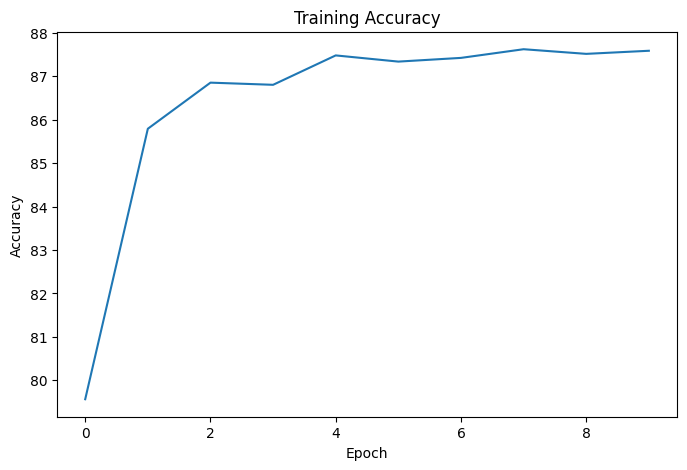

In [46]:
plt.figure(figsize=(8,5))
plt.plot(train_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

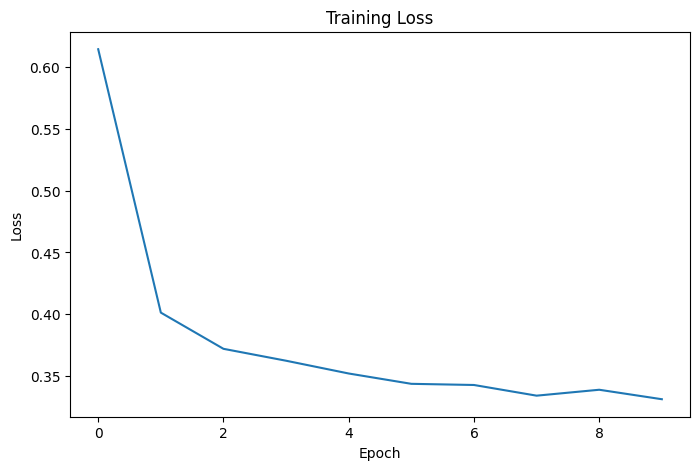

In [47]:
plt.figure(figsize=(8,5))
plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

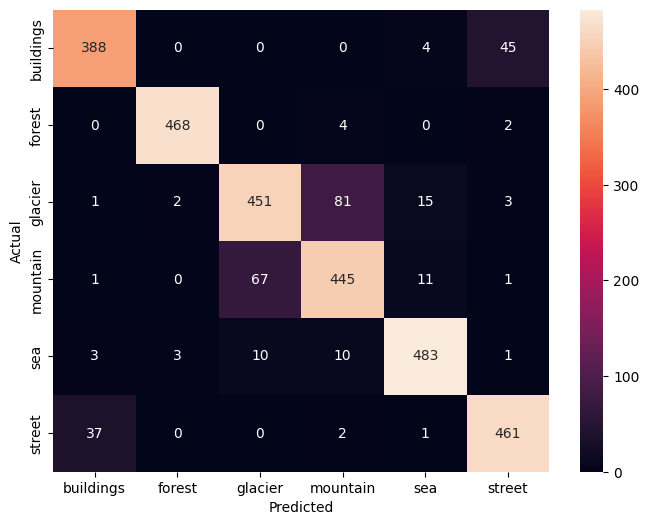

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.90      0.89      0.90       437
      forest       0.99      0.99      0.99       474
     glacier       0.85      0.82      0.83       553
    mountain       0.82      0.85      0.83       525
         sea       0.94      0.95      0.94       510
      street       0.90      0.92      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



# Detecting Overfitting

Overfitting can be identified when:

- Training accuracy keeps increasing.
- Validation accuracy stops improving.
- Validation loss starts increasing.
- Large gap exists between training and validation accuracy.

Example:

Train Accuracy = 98%  
Validation Accuracy = 82%

Solutions:

- Data augmentation
- Dropout
- Early stopping
- Reduce model complexity
- More data

In [50]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

save_model(
    model,
    "Q7_trained_model.pth"
)

In [51]:
def load_model(path):

    model = models.resnet18(pretrained=False)

    num_features = model.fc.in_features

    model.fc = nn.Linear(
        num_features,
        6
    )

    model.load_state_dict(
        torch.load(path)
    )

    model.eval()

    return model

In [52]:
from PIL import Image

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image = test_transform(image)
    image = image.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(image)

        _, pred = torch.max(outputs,1)

    return class_names[pred.item()]

In [53]:
predict_image('/content/predict_sample.jpg')

'forest'

# Files to Submit

- Q7_Intel_Image_Classification.ipynb
- Q7_trained_model.pth
- Q7_output_screenshots.pdf
- Q7_confusion_matrix.png
- Q7_accuracy_loss_curves.png

# Workflow Diagram

Dataset → Preprocessing → Data Augmentation → Transfer Learning (ResNet18) → Training (10 Epochs) → Evaluation → Confusion Matrix → Save Model → Inference on New Images